In [1]:
import pandas as pd
import numpy as np
from ase.io import read, write

## Create xyz from cif

In [2]:



def cifs_to_xyz(path, name):
    df = pd.read_csv(path)
    file_paths = df['file_path'].tolist()

    refcodes = []
    mofs = []

    for cif_path in file_paths:
        refcode = os.path.splitext(os.path.basename(cif_path))[0]
        refcodes.append(refcode)
        mofs.append(read(cif_path))

    write(f'mofs_{name}.xyz', mofs)

    with open(f'refcodes_{name}.csv', 'w') as w:
        w.write(','.join(refcodes))

## Auxiliary function

In [3]:
from scipy.stats import gmean

def get_stats(atomic_nums, tabulated_data):
    vals = np.empty(len(atomic_nums)) * np.nan
    for i in range(len(tabulated_data)):
        vals[(atomic_nums == (i + 1))] = tabulated_data[i]
    stdmean = np.mean(vals)
    geomean = gmean(np.absolute(vals))
    stdev = np.std(vals)
    maxval = np.max(vals)
    minval = np.min(vals)

    return stdmean, geomean, stdev, maxval, minval

## 45 fingerprints script:

In [4]:
import os

tabulated_data_path = '../../fingerprints/generators/tabulated_data'

def generate_45_fingerprints(refcodes_path, xyz_path, name):
    refcodes = np.genfromtxt(refcodes_path, delimiter=',', dtype=str)
    group_data = np.genfromtxt(os.path.join(
        tabulated_data_path, 'group.csv'), delimiter=',')
    period_data = np.genfromtxt(os.path.join(
        tabulated_data_path, 'period.csv'), delimiter=',')
    electroneg_data = np.genfromtxt(
        os.path.join(tabulated_data_path, 'electronegativity.csv'), delimiter=',')
    electron_affin_data = np.genfromtxt(
        os.path.join(tabulated_data_path, 'electron_affinity.csv'), delimiter=',')
    melting_data = np.genfromtxt(os.path.join(
        tabulated_data_path, 'melting_point.csv'), delimiter=',') + 273.15
    boiling_data = np.genfromtxt(os.path.join(
        tabulated_data_path, 'boiling_point.csv'), delimiter=',') + 273.15
    density_data = np.genfromtxt(os.path.join(
        tabulated_data_path, 'density.csv'), delimiter=',')
    ionization_data = np.genfromtxt(
        os.path.join(tabulated_data_path, 'ionization_energy.csv'), delimiter=',')

    mofs = read(xyz_path, index=':')
    data = np.empty((45, len(mofs))) * np.nan
    for i, mof in enumerate(mofs):
        print('Generating fingerprint: ' + str(i))

        atomic_nums = mof.get_atomic_numbers()
        data_vector = np.empty(45) * np.nan

        data_vector[0] = np.mean(atomic_nums)
        data_vector[1] = gmean(atomic_nums)
        data_vector[2] = np.std(atomic_nums)
        data_vector[3] = np.amax(atomic_nums)
        data_vector[4] = np.amin(atomic_nums)

        data_vector[5:10] = get_stats(atomic_nums, group_data)
        data_vector[10:15] = get_stats(atomic_nums, period_data)
        data_vector[15:20] = get_stats(atomic_nums, electroneg_data)
        data_vector[20:25] = get_stats(atomic_nums, electron_affin_data)
        data_vector[25:30] = get_stats(atomic_nums, melting_data)
        data_vector[30:35] = get_stats(atomic_nums, boiling_data)
        data_vector[35:40] = get_stats(atomic_nums, density_data)
        data_vector[40:45] = get_stats(atomic_nums, ionization_data)

        data[:, i] = data_vector

    processed_indices = refcodes[:len(mofs)]

    df = pd.DataFrame(np.transpose(data), index=processed_indices)

    colnames = ['atomic_num_mean', 'atomic_num_geometric_mean', 'atomic_num_standard_deviation', 'atomic_num_max',
                'atomic_num_min',
                'group_num_mean', 'group_num_geometric_mean', 'group_num_standard_deviation', 'group_num_max',
                'group_num_min',
                'period_num_mean', 'period_num_geometric_mean', 'period_num_standard_deviation', 'period_num_max',
                'period_num_min',
                'electronegativity_mean', 'electronegativity_geometric_mean', 'electronegativity_standard_deviation',
                'electronegativity_max', 'electronegativity_min',
                'electron_affinity_mean', 'electron_affinity_geometric_mean', 'electron_affinity_standard_deviation',
                'electron_affinity_max', 'electron_affinity_min',
                'melting_mean', 'melting_geometric_mean', 'melting_standard_deviation', 'melting_max', 'melting_min',
                'boiling_mean', 'boiling_geometric_mean', 'boiling_standard_deviation', 'boiling_max', 'boiling_min',
                'density_mean', 'density_geometric_mean', 'density_standard_deviation', 'density_max', 'density_min',
                'ionization_energy_mean', 'ionization_energy_geometric_mean', 'ionization_energy_standard_deviation',
                'ionization_energy_max', 'ionization_energy_geometric_min']

    df.columns = colnames
    df.index.name = 'MOF'
    df.to_csv(f'stoich45_fingerprints_{name}.csv', index=True)

120 fingerprints script:

In [5]:
from matminer.featurizers.composition import Meredig
from pymatgen.io.ase import AseAtomsAdaptor


# from matminer.featurizers.composition import Meredig
# from pymatgen.io.ase import AseAtomsAdaptor

def generate_120_fingerprints(refcodes_path, xyz_path, name):
    ase_mofs = read(xyz_path, index=':')
    refcodes = np.genfromtxt(refcodes_path, delimiter=',', dtype=str)

    adaptor = AseAtomsAdaptor()
    pm_mofs = [adaptor.get_structure(ase_mof) for ase_mof in ase_mofs]

    featurizer = Meredig()
    all_features = featurizer.feature_labels()

    selected_features = [
        "H fraction", "He fraction", "Li fraction", "Be fraction", "B fraction", "C fraction", "N fraction",
        "O fraction", "F fraction", "Ne fraction",
        "Na fraction", "Mg fraction", "Al fraction", "Si fraction", "P fraction", "S fraction", "Cl fraction",
        "Ar fraction", "K fraction", "Ca fraction",
        "Sc fraction", "Ti fraction", "V fraction", "Cr fraction", "Mn fraction", "Fe fraction", "Co fraction",
        "Ni fraction", "Cu fraction", "Zn fraction",
        "Ga fraction", "Ge fraction", "As fraction", "Se fraction", "Br fraction", "Kr fraction", "Rb fraction",
        "Sr fraction", "Y fraction", "Zr fraction",
        "Nb fraction", "Mo fraction", "Tc fraction", "Ru fraction", "Rh fraction", "Pd fraction", "Ag fraction",
        "Cd fraction", "In fraction", "Sn fraction",
        "Sb fraction", "Te fraction", "I fraction", "Xe fraction", "Cs fraction", "Ba fraction", "La fraction",
        "Ce fraction", "Pr fraction", "Nd fraction",
        "Pm fraction", "Sm fraction", "Eu fraction", "Gd fraction", "Tb fraction", "Dy fraction", "Ho fraction",
        "Er fraction", "Tm fraction", "Yb fraction",
        "Lu fraction", "Hf fraction", "Ta fraction", "W fraction", "Re fraction", "Os fraction", "Ir fraction",
        "Pt fraction", "Au fraction", "Hg fraction",
        "Tl fraction", "Pb fraction", "Bi fraction", "Po fraction", "At fraction", "Rn fraction", "Fr fraction",
        "Ra fraction", "Ac fraction", "Th fraction",
        "Pa fraction", "U fraction", "Np fraction", "Pu fraction", "Am fraction", "Cm fraction", "Bk fraction",
        "Cf fraction", "Es fraction", "Fm fraction",
        "Md fraction", "No fraction", "Lr fraction", "mean AtomicWeight", "mean Column", "mean Row", "range Number",
        "mean Number", "range AtomicRadius",
        "mean AtomicRadius", "range Electronegativity", "mean Electronegativity", "avg s valence electrons",
        "avg p valence electrons", "avg d valence electrons",
        "avg f valence electrons", "frac s valence electrons", "frac p valence electrons", "frac d valence electrons",
        "frac f valence electrons"
    ]

    df = pd.DataFrame(columns=selected_features)

    for i, pm_mof in enumerate(pm_mofs):
        print(f'Generating fingerprint: {i}')
        fingerprint = featurizer.featurize(pm_mof.composition)

        fp_series = pd.Series(fingerprint, index=all_features)

        filtered_fp = fp_series[selected_features]

        refcode = refcodes[i]
        df.loc[refcode, :] = filtered_fp

    df.index.name = 'MOF'
    df.to_csv(f'stoich120_fingerprints_{name}.csv', index=True)


C:\Users\GED\PycharmProjects\Aixelo_Project_DataLab_2025\.venv1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data Visualization

In [6]:
path = '../../qmof_and_odac_match/matched_CO2_qmof_odac.csv'
df_visual = pd.read_csv(path)

In [7]:
print(df_visual.isnull().sum())

df_visual = df_visual.dropna()

MOF                                      0
atomic_num_mean                          0
atomic_num_geometric_mean                0
atomic_num_standard_deviation            0
atomic_num_max                           0
atomic_num_min                           0
group_num_mean                           0
group_num_geometric_mean                 0
group_num_standard_deviation             0
group_num_max                            0
group_num_min                            0
period_num_mean                          0
period_num_geometric_mean                0
period_num_standard_deviation            0
period_num_max                           0
period_num_min                           0
electronegativity_mean                  32
electronegativity_geometric_mean        32
electronegativity_standard_deviation    32
electronegativity_max                   32
electronegativity_min                   32
electron_affinity_mean                   4
electron_affinity_geometric_mean         4
electron_af

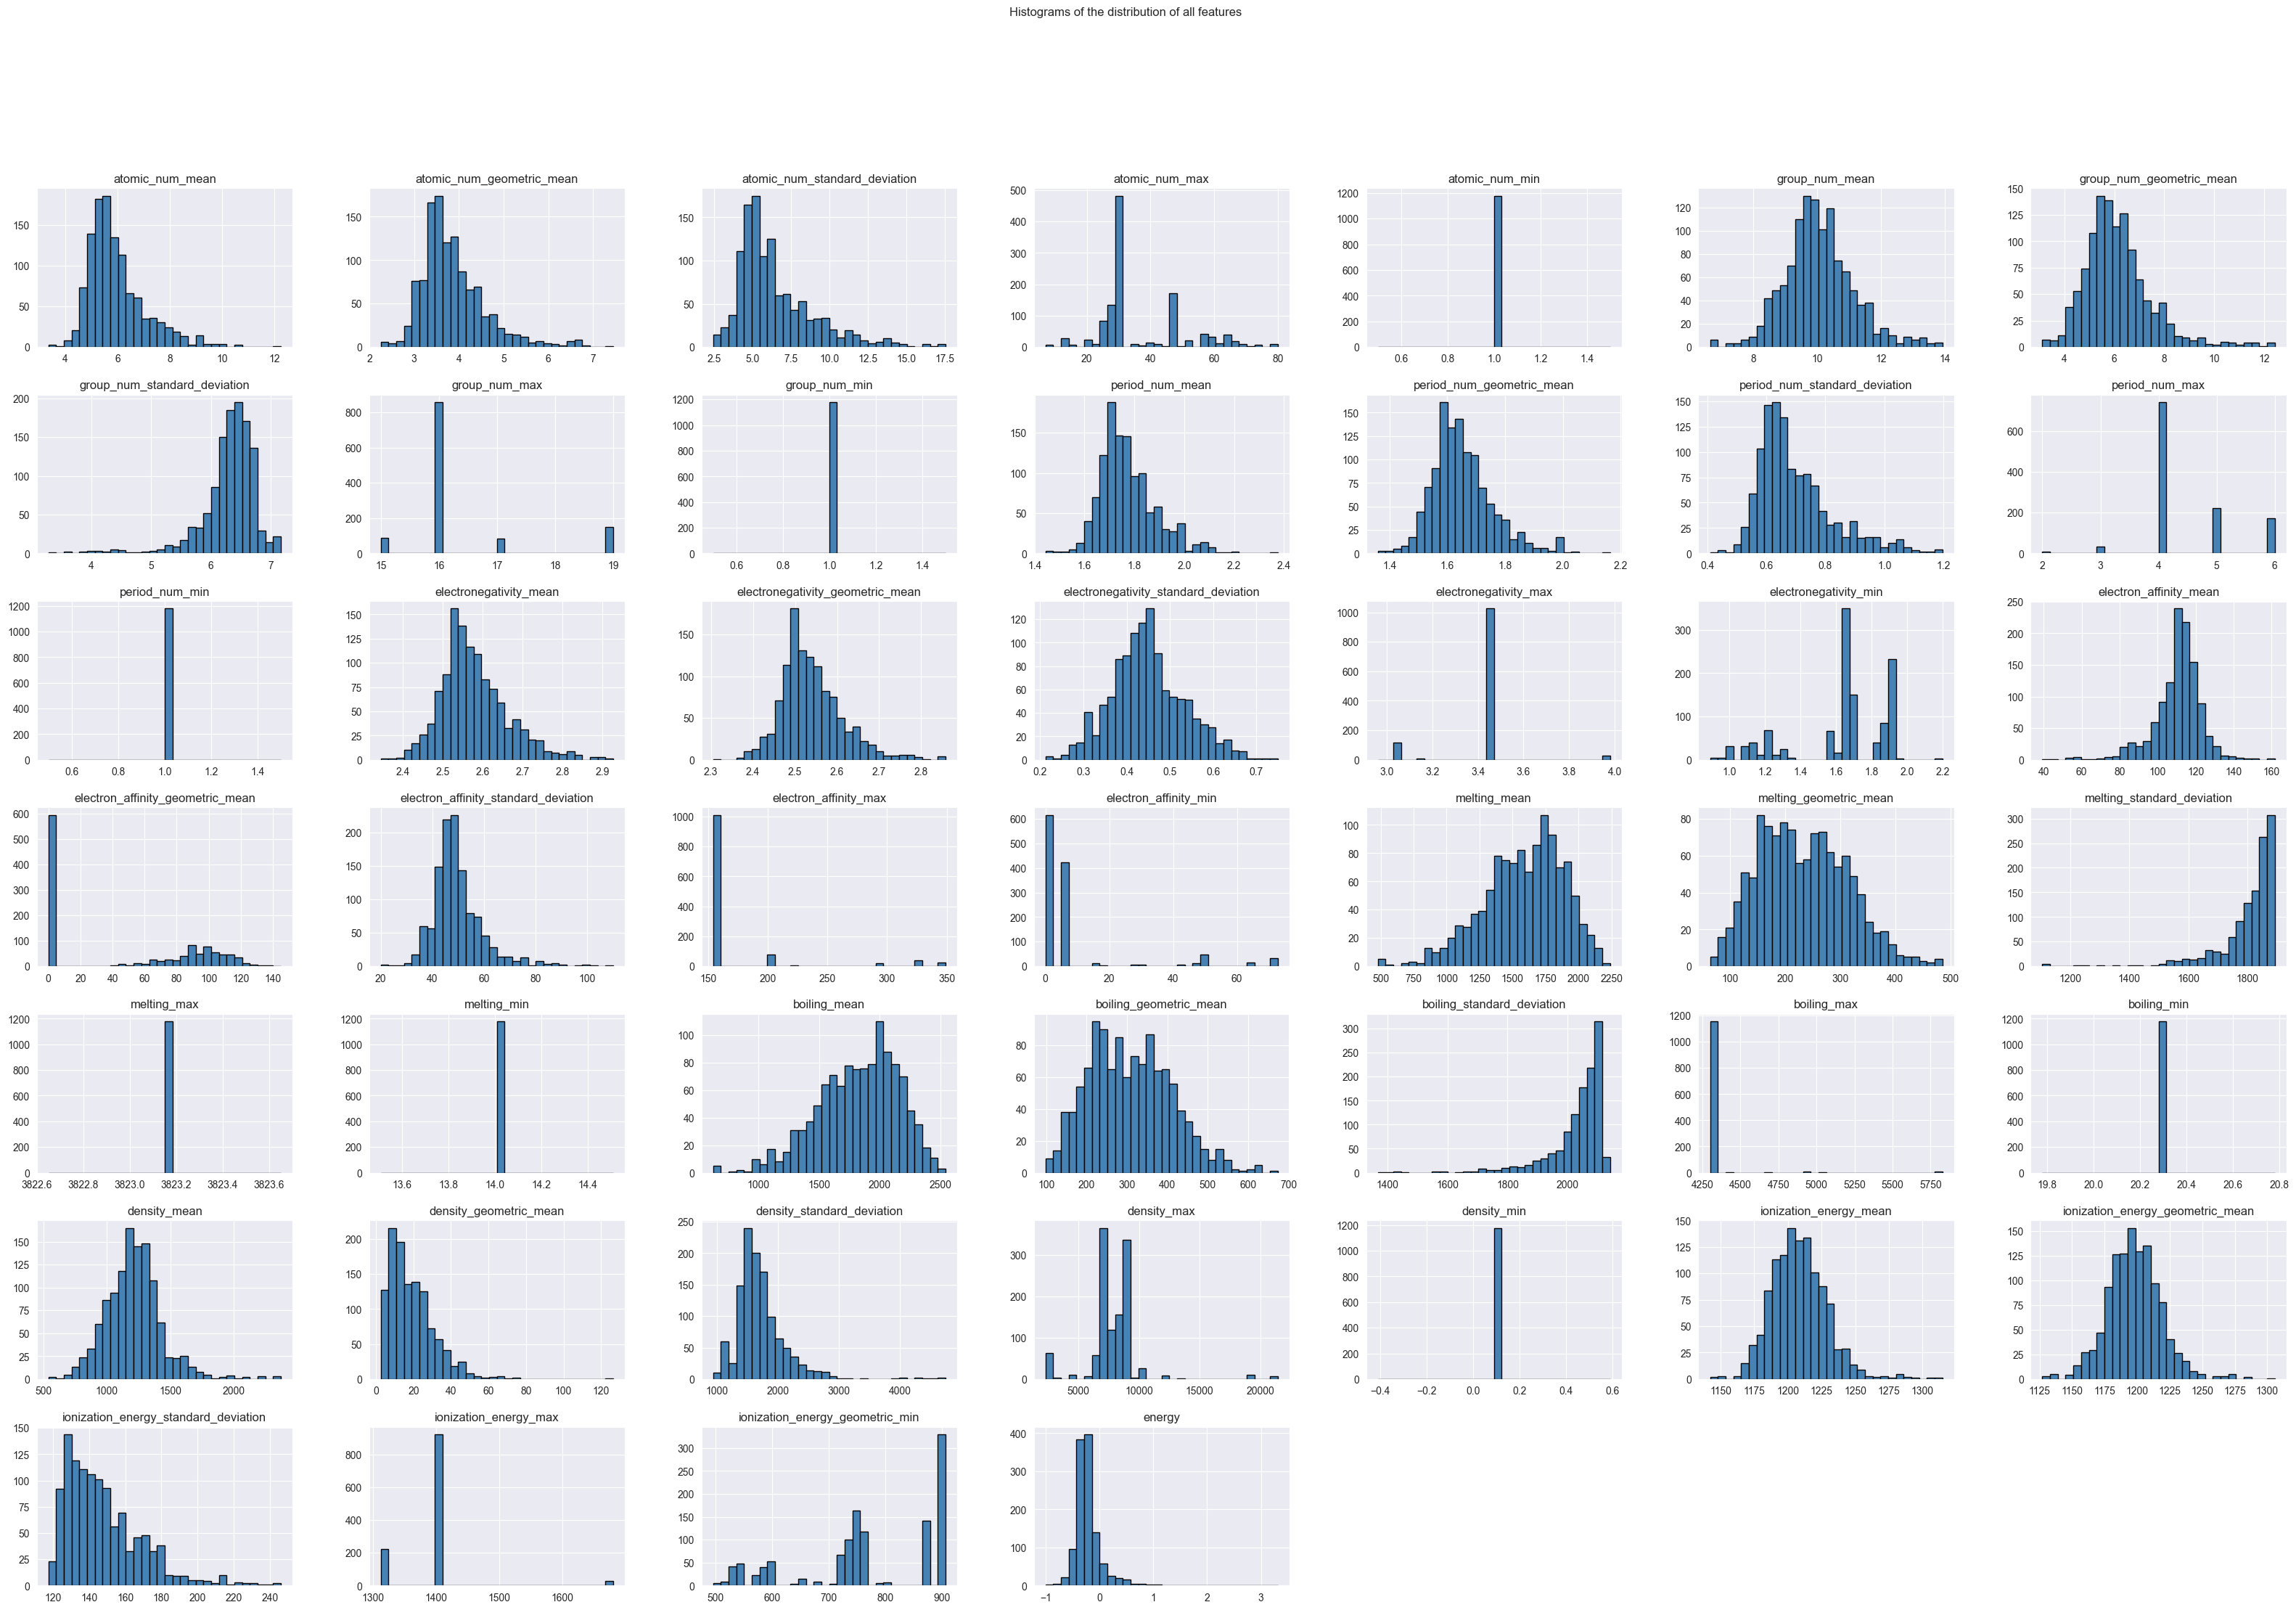

In [8]:
import matplotlib.pyplot as plt

df_visual.hist(bins=30, figsize=(40, 25), color='steelblue', edgecolor='black')
plt.suptitle('Histograms of the distribution of all features')
plt.show()

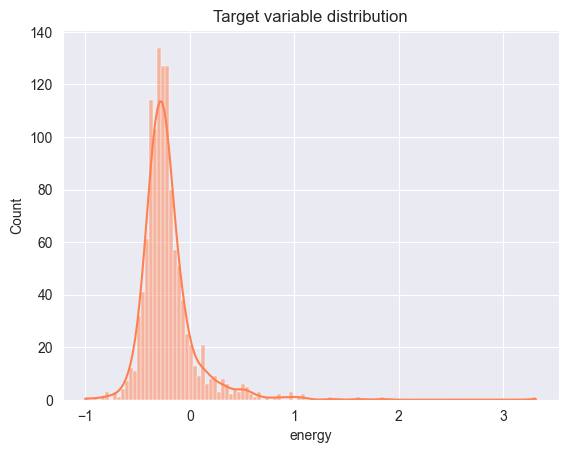

In [9]:
import seaborn as sns


sns.histplot(df_visual['energy'], kde=True, color='coral')
plt.title('Target variable distribution')
plt.show()

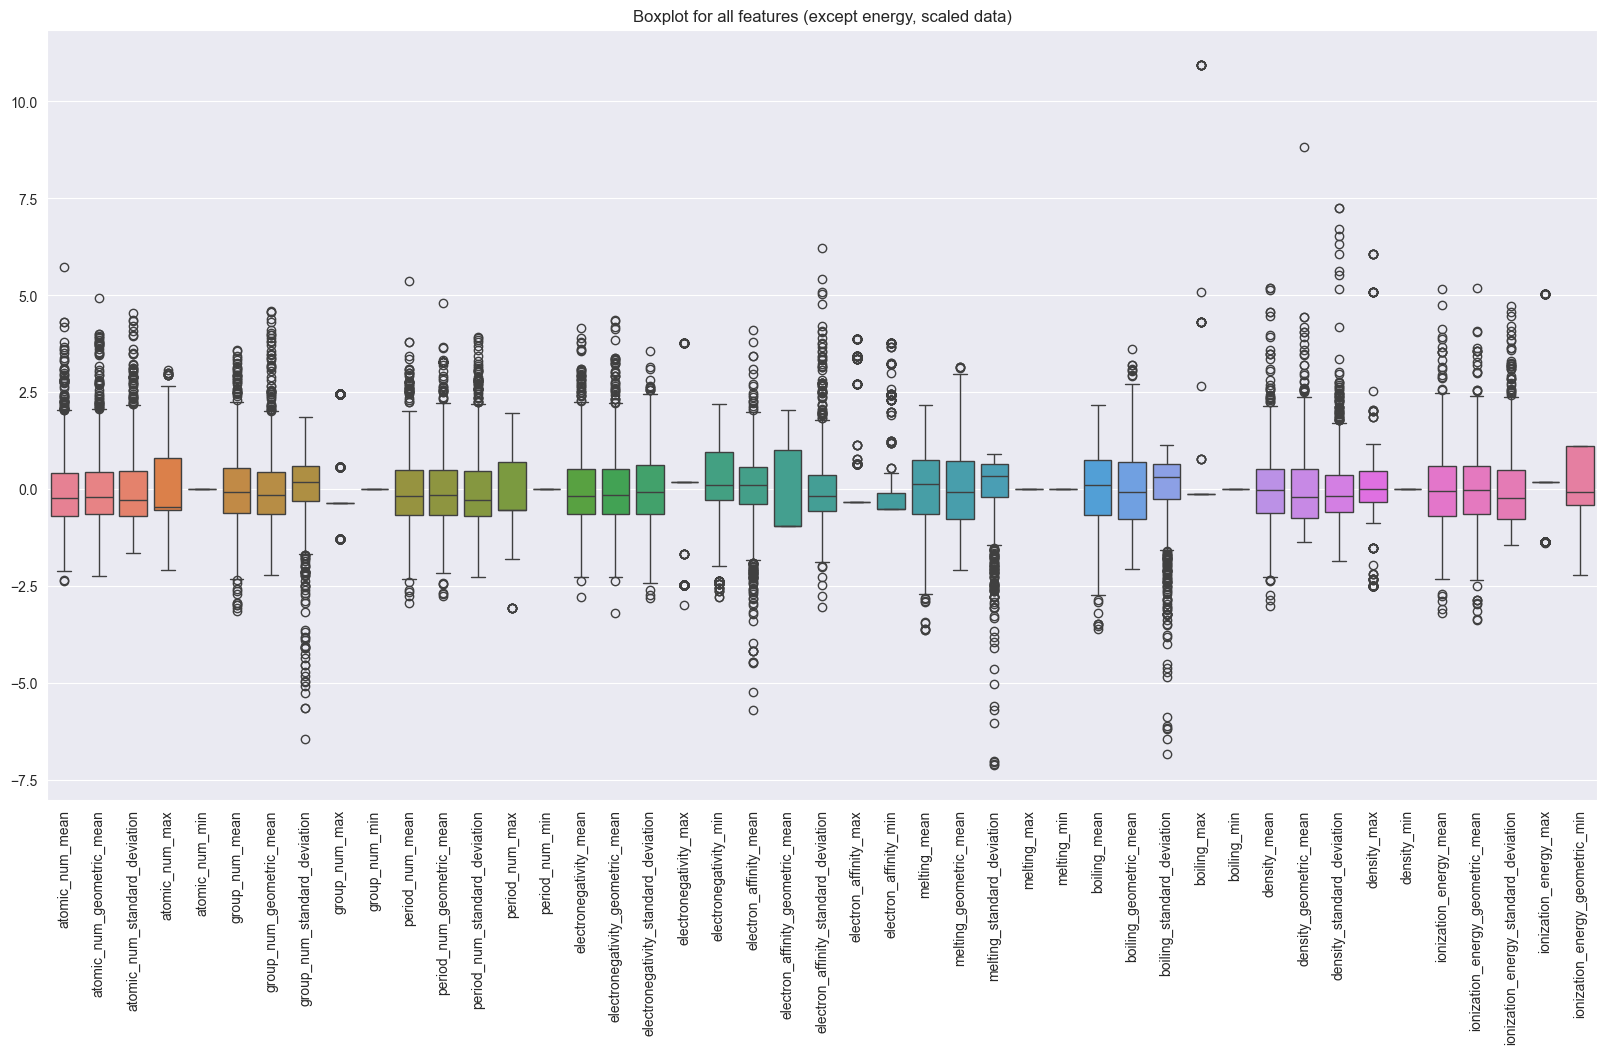

In [10]:
from sklearn.preprocessing import StandardScaler

numeric_features = df_visual.select_dtypes(include=np.number).drop(columns=['energy'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_features)

scaled_df = pd.DataFrame(scaled_data, columns=numeric_features.columns)

plt.figure(figsize=(20, 10))
sns.boxplot(data=scaled_df)
plt.title('Boxplot for all features (except energy, scaled data)')
plt.xticks(rotation=90)
plt.show()



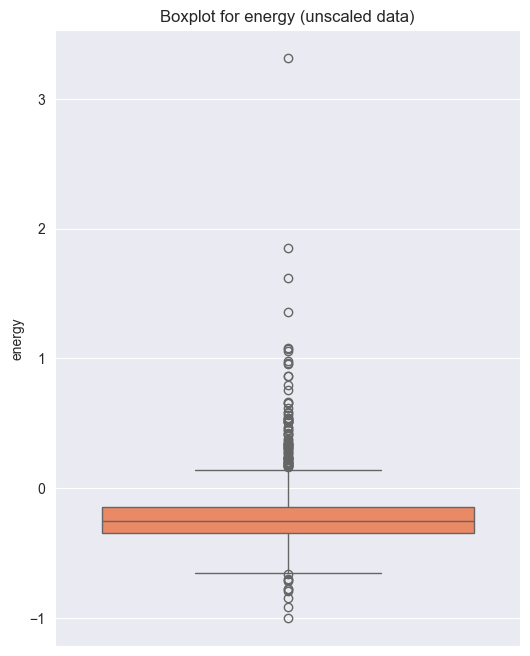

In [11]:
plt.figure(figsize=(6, 8))
sns.boxplot(y=df_visual['energy'], color='coral')
plt.title('Boxplot for energy (unscaled data)')
plt.show()

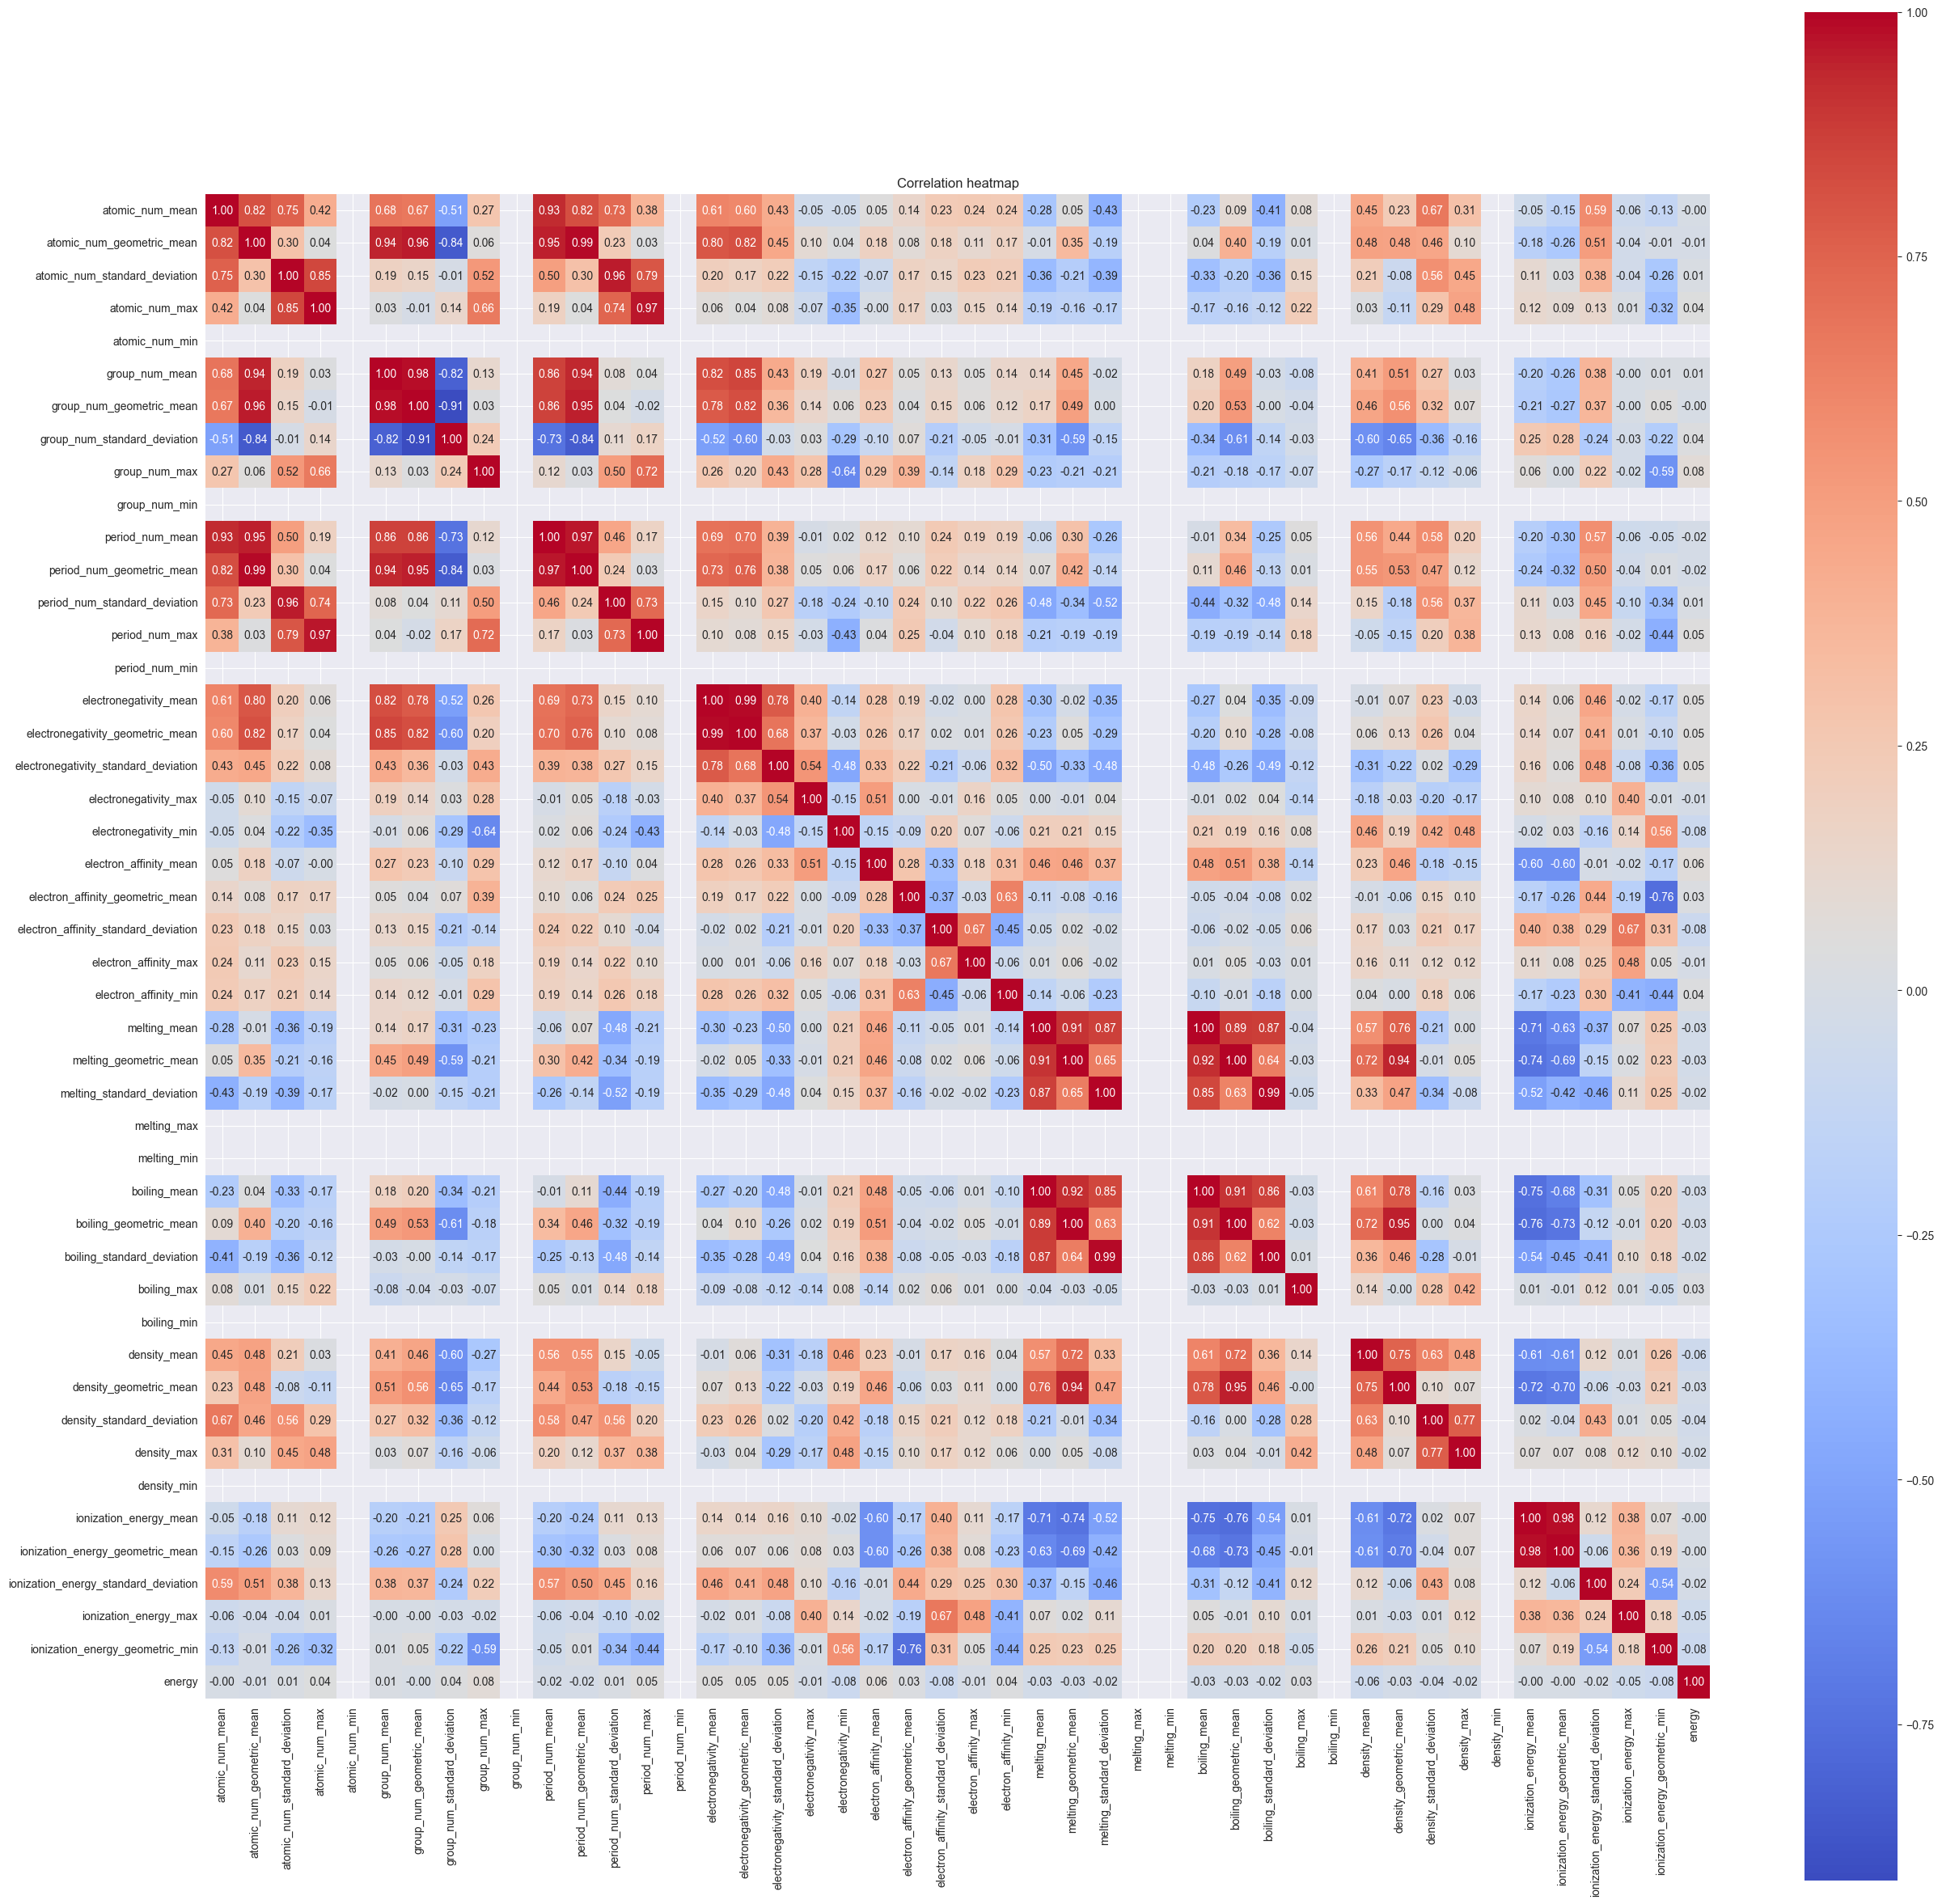

In [12]:
plot_data = df_visual.drop('MOF', axis=1)

plt.figure(figsize=(30, 30))
corr_matrix = plot_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation heatmap')
plt.show()

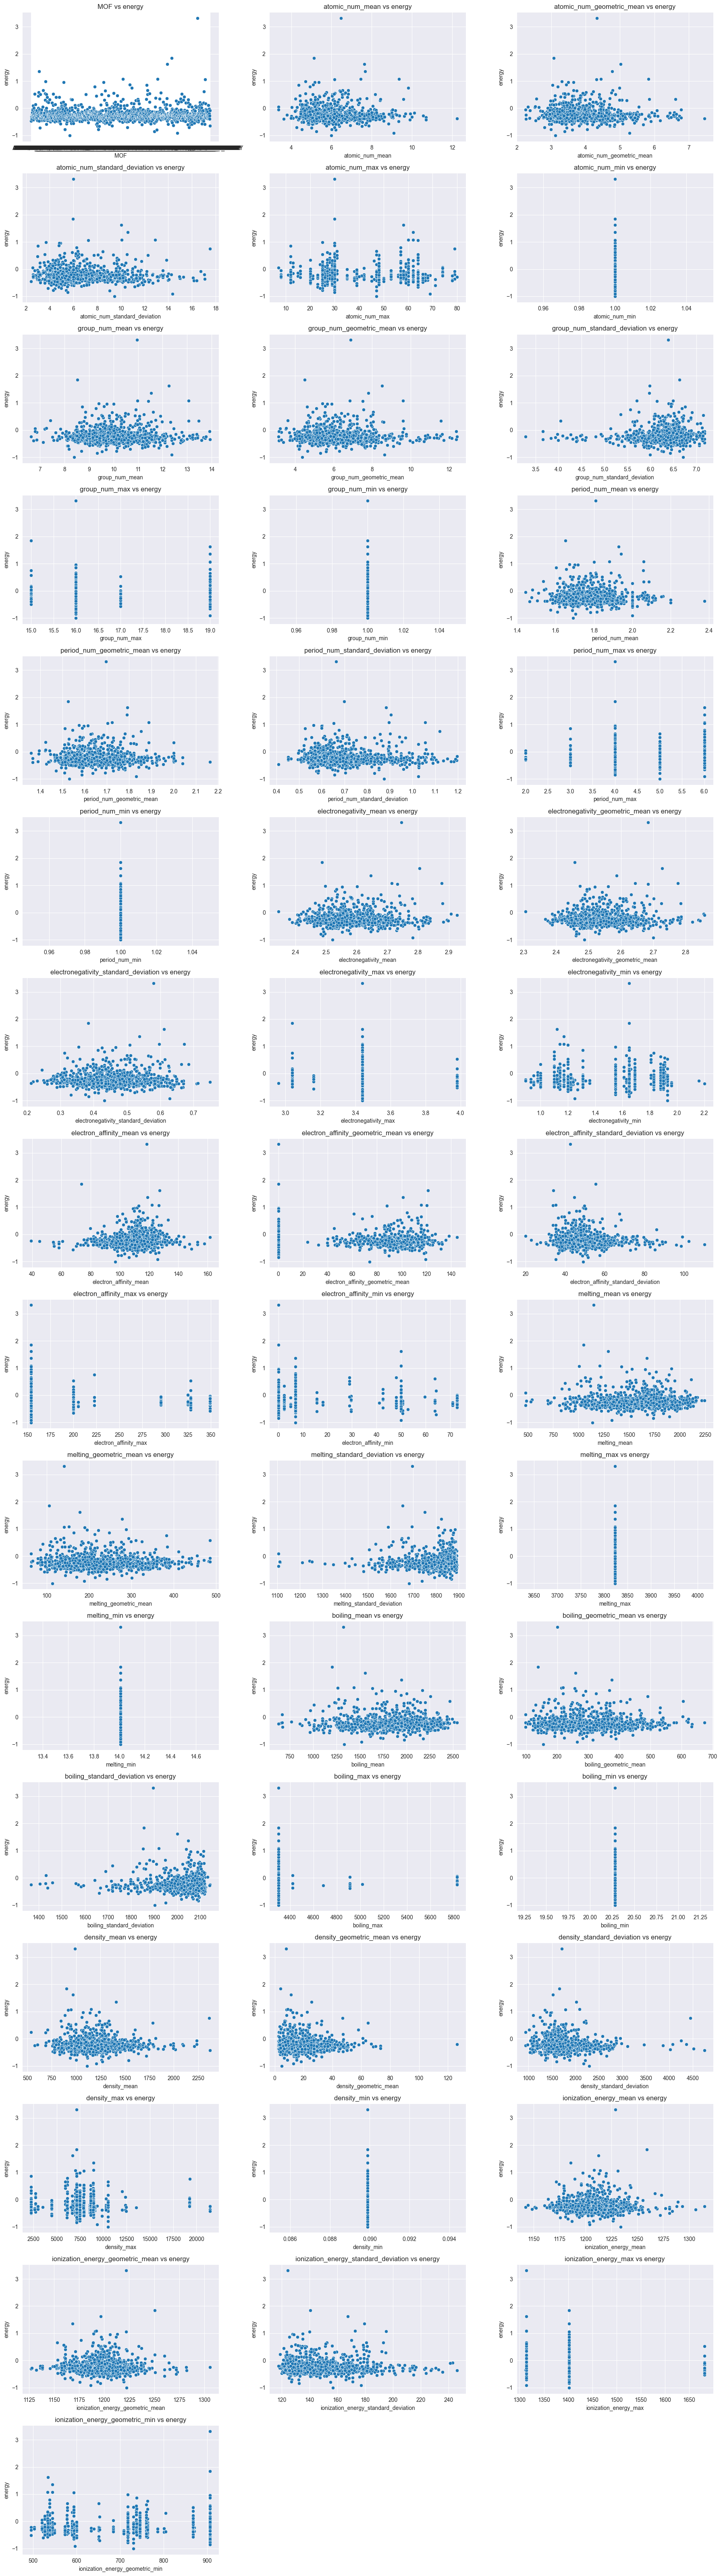

In [13]:
features = [col for col in df_visual.columns if col != 'energy']
n_features = len(features)

cols = 3
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(x=df_visual[col], y=df_visual['energy'], ax=axes[i])
    axes[i].set_title(f'{col} vs energy')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


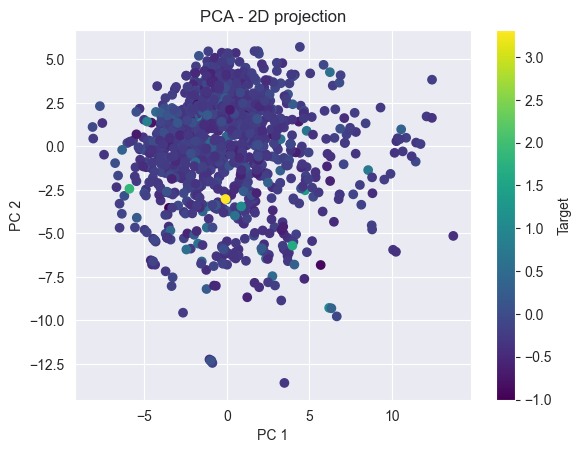

In [14]:
from sklearn.decomposition import PCA



pca_data = df_visual.drop(['energy', 'MOF'], axis=1)


scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=2)
components = pca.fit_transform(pca_data_scaled)

plt.scatter(components[:, 0], components[:, 1], c=df_visual['energy'], cmap='viridis')
plt.colorbar(label='Target')
plt.title('PCA - 2D projection')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

Models Training

In [15]:

def load_data(p):
    return pd.read_csv(p)

In [16]:
loaded_data = load_data(path)

loaded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214 entries, 0 to 1213
Data columns (total 47 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   MOF                                   1214 non-null   object 
 1   atomic_num_mean                       1214 non-null   float64
 2   atomic_num_geometric_mean             1214 non-null   float64
 3   atomic_num_standard_deviation         1214 non-null   float64
 4   atomic_num_max                        1214 non-null   float64
 5   atomic_num_min                        1214 non-null   float64
 6   group_num_mean                        1214 non-null   float64
 7   group_num_geometric_mean              1214 non-null   float64
 8   group_num_standard_deviation          1214 non-null   float64
 9   group_num_max                         1214 non-null   float64
 10  group_num_min                         1214 non-null   float64
 11  period_num_mean  

In [17]:
def remove_outliers(df, multiplier=5):
    initial_shape = df.shape[0]

    df_numeric = df.select_dtypes(include=['number'])
    mask = pd.Series(True, index=df.index)

    for col in df_numeric.columns:
        Q1 = df[col].quantile(0.15)
        Q3 = df[col].quantile(0.85)
        IQR = Q3 - Q1

        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        mask &= df[col].between(lower_bound, upper_bound, inclusive='both')

    cleaned_df = df[mask]
    removed = initial_shape - cleaned_df.shape[0]

    print(f"Removed outliers: {removed}")
    print(f"remaining rows: {cleaned_df.shape[0]}")

    return cleaned_df


In [18]:
data = loaded_data.drop(columns=['MOF'])

data = remove_outliers(data)

Removed outliers: 399
remaining rows: 815


In [19]:
X = data.drop(columns=['energy'])
y = data['energy']

In [20]:
print(f"Mean value: {np.mean(y):.4f}")
print(f"Average value: {np.average(y):.4f}")
print(f"Maximum value: {np.max(y):.4f}")
print(f"Minimum value: {np.min(y):.4f}")
print(f"Standard deviation: {np.std(y):.4f}")
print(f"Median value: {np.median(y):.4f}")
print(f"Number of samples: {len(y)}")

Mean value: -0.2229
Average value: -0.2229
Maximum value: 1.3594
Minimum value: -1.0025
Standard deviation: 0.2452
Median value: -0.2690
Number of samples: 815


In [21]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [22]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


In [23]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', keep_empty_features=True)),
    # ('imputer', SimpleImputer(strategy='constant', fill_value=0, keep_empty_features=True)),
    ('scaler', StandardScaler()),
])

In [24]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def print_error(name, y_valid, pred):
    print('---------------------------------------------------------\n')
    print(f'Model: {name}')

    mae = mean_absolute_error(y_valid, pred)
    mse = mean_squared_error(y_valid, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_valid, pred)

    random_indices = np.random.choice(len(y_valid), 5, replace=False)
    print("\nRandom 5 predictions vs actual values:")
    for idx in random_indices:
        print(f"Predicted: {pred[idx]:.4f}, Actual: {y_valid.iloc[idx]:.4f}")

    print(f"\nMean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R² Score: {r2 * 100:.2f}%")


Simple Models training

In [25]:
pipeline_reg = Pipeline([
    ('regressor', RandomForestRegressor())
])

param_grid = {
    'regressor': [
        RandomForestRegressor(n_estimators=100, random_state=42),
        ExtraTreesRegressor(n_estimators=100, random_state=42),
        BaggingRegressor(n_estimators=100, random_state=42)
    ]
}


In [26]:
X_train_transformed = pipeline.fit_transform(X_train)
X_valid_transformed = pipeline.transform(X_valid)

In [27]:
grid_search = GridSearchCV(pipeline_reg,
                           param_grid,
                           cv=5,
                           scoring='r2',
                           return_train_score=True
                           )
grid_search.fit(X_train_transformed, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor': [RandomForestR...ndom_state=42), ExtraTreesReg...ndom_state=42), ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [28]:
y_pred = grid_search.best_estimator_.predict(X_valid_transformed)
print_error('Grid', y_valid, y_pred)

---------------------------------------------------------

Model: Grid

Random 5 predictions vs actual values:
Predicted: -0.1835, Actual: 0.5309
Predicted: -0.3356, Actual: -0.1360
Predicted: -0.1458, Actual: -0.3687
Predicted: -0.2383, Actual: -0.3800
Predicted: -0.2761, Actual: -0.0980

Mean Absolute Error (MAE): 0.18807502248105396
Mean Squared Error (MSE): 0.0727539526580613
Root Mean Squared Error (RMSE): 0.26972940636508524
R² Score: -36.82%


Cross Validation

In [29]:
from sklearn.model_selection import cross_val_score, KFold

model = RandomForestRegressor(n_estimators=100, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_train_transformed, y_train, cv=kf)

print("score of every fold:", scores)
print("Average score:", np.mean(scores))

score of every fold: [ 0.01347145 -0.13784666 -0.06188933  0.00740147 -0.25600255]
Average score: -0.08697312362769023


In [30]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_train_transformed, y_train,
                          scoring='neg_mean_squared_error', cv=kf)

print("MSE of every fold:", -scores)
print("Average MSE score:", -np.mean(scores))

MSE of every fold: [0.0747619  0.0563457  0.08257806 0.07286193 0.03279308]
Average MSE score: 0.06386813447797411


GridSearch:

In [31]:
param_grid_rf = {
    'pca__n_components': [10, 15, 20, 30, 40, 45],
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt', 'log2'],
    'model__bootstrap': [True, False]
}

param_grid_et = {
    'pca__n_components': [10, 15, 20, 30, 40, 45],
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt', 'log2']
}

In [32]:
from sklearn.decomposition import PCA

pipe_rf = Pipeline([
    ('pca', PCA(random_state=42)),
    ('model', RandomForestRegressor(random_state=42))
])

pipe_et = Pipeline([
    ('pca', PCA(random_state=42)),
    ('model', ExtraTreesRegressor(random_state=42))
])

In [33]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=2
)


grid_et = GridSearchCV(
    estimator=pipe_et,
    param_grid=param_grid_et,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_rf.fit(X_train_transformed, y_train)
print("\nBest params for RandomForest:")
print(grid_rf.best_params_)
print("Best result (RMSE):", -grid_rf.best_score_)

Fitting 5 folds for each of 3888 candidates, totalling 19440 fits


In [ ]:
grid_et.fit(X_train_transformed, y_train)
print("\nBest params for ExtraTrees:")
print(grid_et.best_params_)
print("Best result (RMSE):", -grid_et.best_score_)

In [ ]:
y_pred = grid_rf.best_estimator_.predict(X_valid_transformed)
print_error('RandomForest', y_valid, y_pred)

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(y_valid, y_pred, alpha=0.5)
plt.plot([min(y_valid), max(y_valid)], [min(y_valid), max(y_valid)], 'r--', linewidth=2)  # линия y=x
plt.xlabel('True Energy')
plt.ylabel('Predicted Energy')
plt.grid(True)
plt.show()

In [ ]:
y_pred = grid_et.best_estimator_.predict(X_valid_transformed)
print_error('ExtraTrees', y_valid, y_pred)

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(y_valid, y_pred, alpha=0.5)
plt.plot([min(y_valid), max(y_valid)], [min(y_valid), max(y_valid)], 'r--', linewidth=2)  # линия y=x
plt.xlabel('True Energy')
plt.ylabel('Predicted Energy')
plt.grid(True)
plt.show()